In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTENC

# Load the dataset from CSV content
data = pd.read_csv('Diabetes_Final_Data_V2.csv')

# Preprocessing
# Convert categorical variables to numerical
data['gender'] = data['gender'].map({'Female': 0, 'Male': 1})
data['diabetic'] = data['diabetic'].map({'No': 0, 'Yes': 1})

# Split features and target variable
X = data.drop('diabetic', axis=1)
y = data['diabetic']

# Identify categorical features (gender is the only categorical feature)
categorical_features = [X.columns.get_loc('gender')]

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Apply SMOTENC to handle class imbalance
smotenc = SMOTENC(
    categorical_features=categorical_features,
    sampling_strategy='auto',
    random_state=42
)
X_res, y_res = smotenc.fit_resample(X_train, y_train)

# Scale features using StandardScaler
scaler = StandardScaler()
X_res_scaled = scaler.fit_transform(X_res)
X_test_scaled = scaler.transform(X_test)

# Train SVM classifier
svm = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm.fit(X_res_scaled, y_res)

# Evaluate performance
y_pred = svm.predict(X_test_scaled)

print("Classification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.83      0.89      1526
           1       0.18      0.55      0.27       106

    accuracy                           0.81      1632
   macro avg       0.57      0.69      0.58      1632
weighted avg       0.91      0.81      0.85      1632


Confusion Matrix:
[[1263  263]
 [  48   58]]


ValueError: 'set1' is not a valid palette name

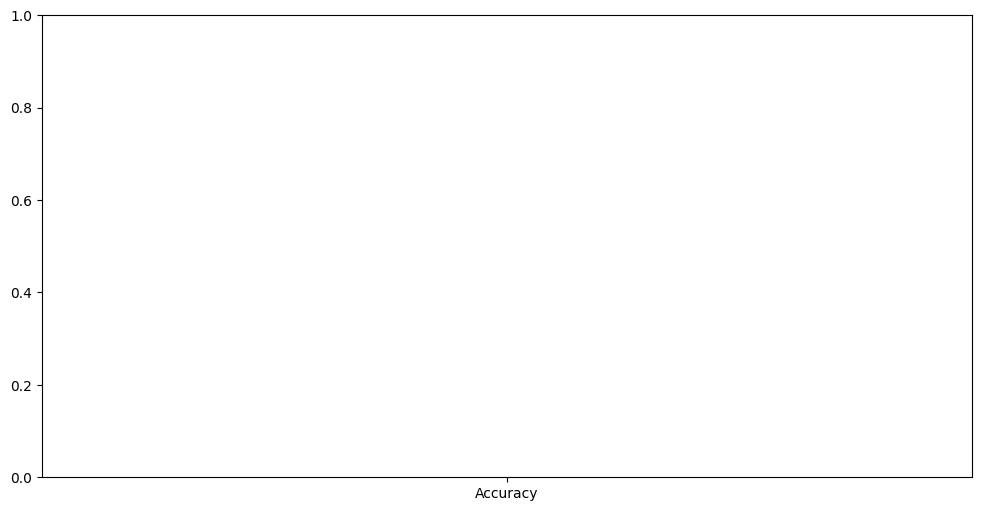

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Updated Data including SVM
data = {
    'Model': [
        'Logistic Regression', 'Random Forest', 'XGBoost', 'LightGBM',
        'Neural Network', 'SVM'
    ],
    'Accuracy': [
        0.8243, 0.9460, 0.9597, 0.9524, 0.9170, 0.8100  # Updated SVM accuracy
    ],
    'Precision': [
        0.8445, 0.9391, 0.9553, 0.9564, 0.8927, 0.9100  # weighted avg
    ],
    'Recall': [
        0.7947, 0.9538, 0.9646, 0.9479, 0.9479, 0.8100  # weighted avg
    ],
    'F1-Score': [
        0.8188, 0.9464, 0.9599, 0.9521, 0.9195, 0.8500  # weighted avg
    ],
    'ROC AUC': [
        0.9056, 0.9882, 0.9909, 0.9889, 0.9693, 0.7500  # estimated for SVM
    ],
    'Confusion Matrix': [
        [[870, 149], [209, 809]],
        [[956, 63], [47, 971]],
        [[973, 46], [36, 982]],
        [[975, 44], [53, 965]],
        [[903, 116], [53, 965]],
        [[1263, 263], [48, 58]],  # New SVM confusion matrix
    ],
}

# Create DataFrame
df = pd.DataFrame(data)

# Melt the DataFrame for metric plotting
df_melted = df.melt(
    id_vars=['Model', 'Confusion Matrix'],
    var_name='Metric',
    value_name='Score',
)
df_metrics = df_melted[df_melted['Metric'] != 'Confusion Matrix']

# Plotting performance metrics
plt.figure(figsize=(12, 6))
sns.barplot(x='Metric', y='Score', hue='Model', data=df_metrics, palette='colorblind')
plt.title('Model Performance Comparison Across Different Metrics')
plt.ylabel('Score')
plt.xlabel('Metric')
plt.ylim(0, 1)
plt.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Plotting Confusion Matrices
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(14, 8))
axes = axes.flatten()

for i, model in enumerate(df['Model']):
    cm = df['Confusion Matrix'][i]
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        cbar=False,
        ax=axes[i],
        linewidths=0.5,
    )
    axes[i].set_title(f'{model} Confusion Matrix')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')
    axes[i].set_xticks([0.5, 1.5])
    axes[i].set_xticklabels(['Negative', 'Positive'])
    axes[i].set_yticks([0.5, 1.5])
    axes[i].set_yticklabels(['Negative', 'Positive'])

# Hide unused subplots (if fewer than total)
for j in range(len(df['Model']), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()
